# 06 - Ablations

Builds ablation suites for ridge degree, mRMR objectives, target/predictor variants, IRT variants, and optional Pearson plots.

In [2]:
print(5)

5


In [12]:
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "mrmr").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate project root containing mrmr/")


PROJECT_ROOT = find_project_root(Path.cwd())
NOTEBOOK_DIR = PROJECT_ROOT / "mrmr" / "viz" / "notebooks"
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import importlib
import nb_utils as _nb_utils

_nb_utils = importlib.reload(_nb_utils)

BINARY_DATASETS_DEFAULT = _nb_utils.BINARY_DATASETS_DEFAULT
CONTINUOUS_DATASETS_DEFAULT = _nb_utils.CONTINUOUS_DATASETS_DEFAULT
PASSK_BENCHMARKS_DEFAULT = _nb_utils.PASSK_BENCHMARKS_DEFAULT
build_mrmr_methods = _nb_utils.build_mrmr_methods
run_notebook_06_ablation_1a = _nb_utils.run_notebook_06_ablation_1a
run_notebook_06_ablation_1b = _nb_utils.run_notebook_06_ablation_1b
run_notebook_06_ablation_2 = _nb_utils.run_notebook_06_ablation_2
run_notebook_06_ablation_3 = _nb_utils.run_notebook_06_ablation_3
run_notebook_06_ablation_4 = _nb_utils.run_notebook_06_ablation_4
run_notebook_06_ablation_5 = _nb_utils.run_notebook_06_ablation_5

BINARY_DATASETS = [
    "ifeval",
    "openllm_math",
    "mmlu_pro",
    "arc_challenge",
    "bbh",
    "gpqa",
    "musr",
    "commonsense",
    "gsm",
    "legalbench",
    "math",
    "med_qa",
    "mmlu",
]

CONTINUOUS_DATASETS = [
    "biolaysumm_rougel",
    "biolaysumm_bertscore",
    "biolaysumm_fkgl",
    "govreport_rougel",
    "govreport_bertscore",
    "truthfulqa_judge",
    # "nemotron_pii",
]

PASSK_BENCHMARKS = [
    # ,
    "LBPP_Python",
    "HumanEvalPack_PythonPlus",
    "MBPPPlus_mbpp_plus",
    "MBPP_mbpp",
]

BINARY_DATASETS = BINARY_DATASETS or BINARY_DATASETS_DEFAULT
CONTINUOUS_DATASETS = CONTINUOUS_DATASETS or CONTINUOUS_DATASETS_DEFAULT
PASSK_BENCHMARKS = PASSK_BENCHMARKS or PASSK_BENCHMARKS_DEFAULT

# -------------------------------
# Data-setting controls
# -------------------------------
FIXED_NMODELS_BINARY = "30"
FIXED_NMODELS_CONTINUOUS = "32"
FIXED_NMODELS_PASSK = "15"
FIXED_CORESET = "10%"

# -------------------------------
# Method controls
# -------------------------------
ABLATION_1A_METHODS: list[str | tuple[str, ...]] = [
    "random_sampling",
    "random_sampling_and_learn",
    "krandom_sampling_and_learn",
    "k3random_sampling_and_learn",
    "k4random_sampling_and_learn",
    "random_search_and_learn",
    "krandom_search_and_learn",
    "k3random_search_and_learn",
    "k4random_search_and_learn",
    
    "anchor_points_weighted+",
    "kanchor_points_weighted+",
    "k3anchor_points_weighted+",
    "k4anchor_points_weighted+",

    "gpirt1+",
    "kgpirt1+",
    "k3gpirt1+",
    "k4gpirt1+",
]
ABLATION_1A_METHODS += [
    (m, m.replace("5_", "_"))
    for m in build_mrmr_methods(degrees=[1, 2, 3, 4], mi_ks=[5], objectives=["MIQ"], targets=["y"])
]

ABLATION_2_MIK_VALUES = [
    3,
    4,
    5,
    6,
    7,
    8,
    9,
]

ABLATION_3_METHODS: list[str | tuple[str, ...]] = [
    ("mrmr5_MIQ_y", "mrmr_MIQ_y"),
    ("mrmr5_MIQ_PC1", "mrmr_MIQ_PC1"),
    ("kmrmr5_MIQ_y", "kmrmr_MIQ_y"),
    ("kmrmr5_MIQ_PC1", "kmrmr_MIQ_PC1"),
    ("rfmrmr5_MIQ_y", "rfmrmr_MIQ_y"),
    ("rfmrmr5_MIQ_PC1", "rfmrmr_MIQ_PC1"),
    ("lmrmr5_MIQ_y", "lmrmr_MIQ_y"),
    ("lmrmr5_MIQ_PC1", "lmrmr_MIQ_PC1"),
]

ABLATION_4_BINARY_METHODS: list[str | tuple[str, ...]] = [
    ("gpirt", "gpirt10"),
    ("gpirt5",),
    ("gpirt1",),
    ("pirt", "pirt10"),
    ("pirt5",),
    ("pirt1",),
]

ABLATION_4_CONT_METHODS: list[str | tuple[str, ...]] = [
    ("LEGO_gpirt", "LEGO_gpirt10"),
    ("LEGO_gpirt5",),
    ("LEGO_gpirt1",),
    ("LEGO_pirt", "LEGO_pirt10"),
    ("LEGO_pirt5",),
    ("LEGO_pirt1",),
    ("B_gpirt", "B_gpirt10"),
    ("B_gpirt5",),
    ("B_gpirt1",),
    ("B_pirt", "B_pirt10"),
    ("B_pirt5",),
    ("B_pirt1",),
    ("G_gpirt", "G_gpirt1"),
    ("G_pirt", "G_pirt1"),
    ("B3_v2_gpirt", "B3_v2_gpirt1"),
    ("B3_v2_pirt", "B3_v2_pirt1"),
]

ABLATION_5_BINARY_METHODS: list[str | tuple[str, ...]] = [
    "random_sampling",
    # "lasso",
    "random_sampling_and_learn",
    "krandom_sampling_and_learn",
    "random_search_and_learn",
    "krandom_search_and_learn",
    "anchor_points_weighted",
    "anchor_points_weighted+",
    "kanchor_points_weighted+",
    # "pirt1",
    # "pirt1+",
    # "kpirt1+",
    "gpirt1",
    "gpirt1+",
    "kgpirt1+",
]
ABLATION_5_BINARY_METHODS += [
    (m, m.replace("5_", "_"))
    for m in build_mrmr_methods(degrees=[1, 2], mi_ks=[5], objectives=["MIQ"], targets=["y"])
]

ABLATION_5_CONT_METHODS: list[str | tuple[str, ...]] = [
    "random_sampling",
    # "lasso",
    "random_sampling_and_learn",
    "krandom_sampling_and_learn",
    "random_search_and_learn",
    "krandom_search_and_learn",
    "anchor_points_weighted",
    "anchor_points_weighted+",
    "kanchor_points_weighted+",
    # ("LEGO_gpirt", "gpirt"),
    # ("B_pirt5", "pirt"),
    # ("B_pirt5+", "pirt+"),
    # ("kB_pirt5+", "pirt+"),
    ("B_gpirt5", "gpirt"),
    ("B_gpirt5+", "gpirt+"),
    ("kB_gpirt5+", "gpirt+"),
]
ABLATION_5_CONT_METHODS += [
    (m, m.replace("5_", "_"))
    for m in build_mrmr_methods(degrees=[1, 2], mi_ks=[3], objectives=["PMIQ"], targets=["y"])
]

COMMON_ABLATION_KWARGS = dict(
    binary_datasets=BINARY_DATASETS,
    continuous_datasets=CONTINUOUS_DATASETS,
    passk_benchmarks=PASSK_BENCHMARKS,
    fixed_nmodels_binary=FIXED_NMODELS_BINARY,
    fixed_nmodels_continuous=FIXED_NMODELS_CONTINUOUS,
    fixed_nmodels_passk=FIXED_NMODELS_PASSK,
    fixed_coreset=FIXED_CORESET,
    ablation_1a_methods=ABLATION_1A_METHODS,
    ablation_2_mik_values=ABLATION_2_MIK_VALUES,
    ablation_3_methods=ABLATION_3_METHODS,
    ablation_4_binary_methods=ABLATION_4_BINARY_METHODS,
    ablation_4_cont_methods=ABLATION_4_CONT_METHODS,
    ablation_5_binary_methods=ABLATION_5_BINARY_METHODS,
    ablation_5_cont_methods=ABLATION_5_CONT_METHODS,
    save_outputs=True,
    show_saved_plots=False,
    return_figures=True,
    close_figures=False,
)

[PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/06_ablations/ablation_1a_binary_with_random.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/06_ablations/ablation_1a_binary_no_random.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/06_ablations/tables/ablation_1a_binary.tex')]
ablation_1a_binary_with_random.pdf


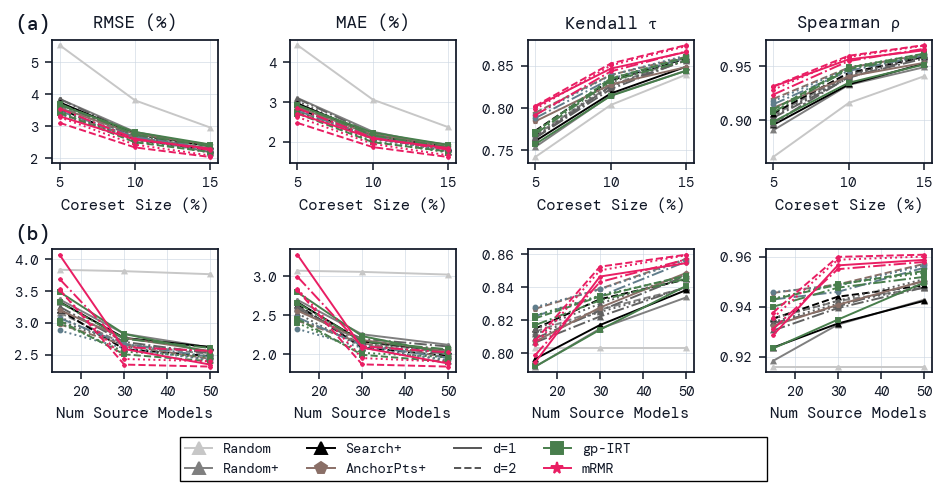

ablation_1a_binary_no_random.pdf


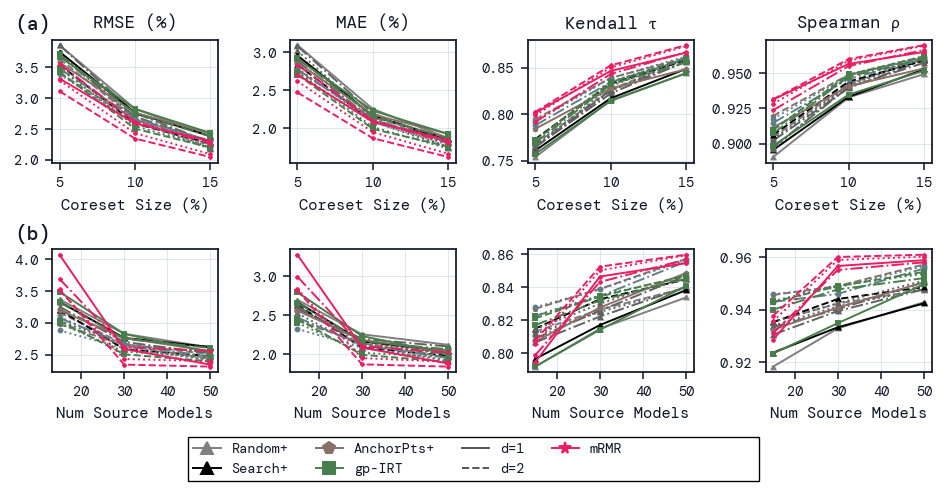

In [4]:
# Ablation 1A
outputs_1a, figures_1a = run_notebook_06_ablation_1a(**COMMON_ABLATION_KWARGS)
print(outputs_1a)
import matplotlib.pyplot as plt
for key, fig in figures_1a.items():
    print(key)
    display(fig)
    plt.close(fig)

[PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/06_ablations/ablation_1b_binary_metric_vs_degree.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/06_ablations/ablation_1b_binary_metric_vs_degree_plus.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/06_ablations/ablation_1b_continuous_metric_vs_degree.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/06_ablations/ablation_1b_continuous_metric_vs_degree_plus.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/06_ablations/ablation_1b_passk_k1_metric_vs_degree.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/06_ablations/ablation_1b_passk_k1_metric_vs_degree_plus.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/06_ablations/ablation_1b_passk_kopt_metric_vs_degree.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/06_ablations/ablation_1b_passk_kopt_metric_vs_degree_plus.pdf'), PosixPa

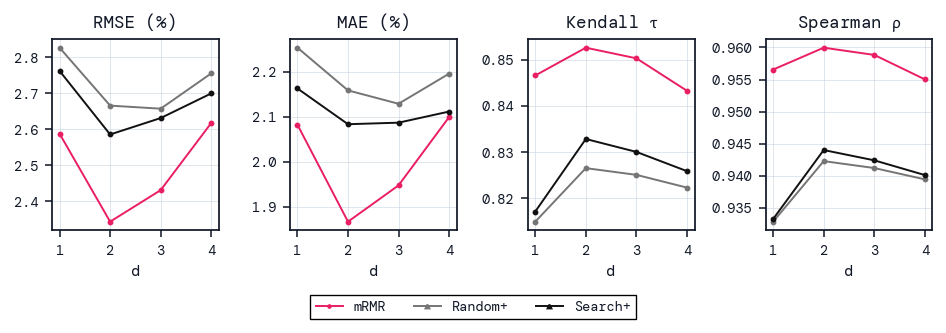

ablation_1b_binary_metric_vs_degree_plus.pdf


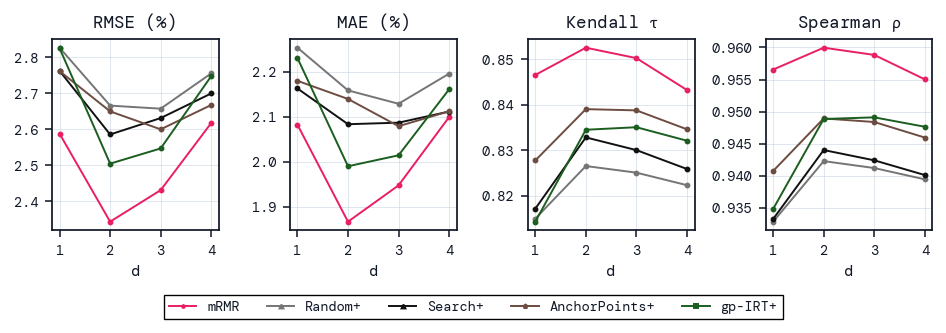

ablation_1b_continuous_metric_vs_degree.pdf


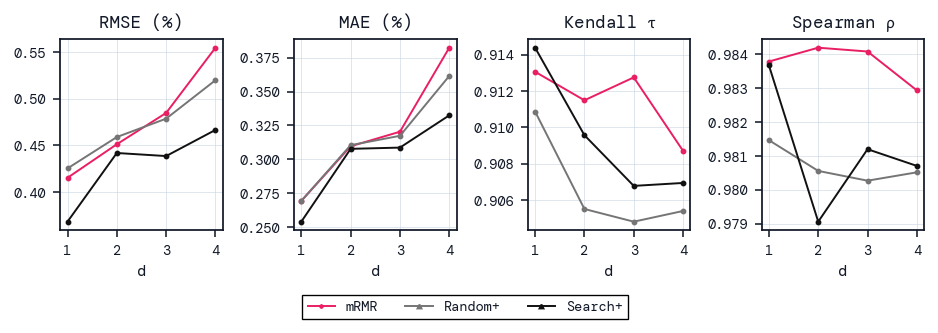

ablation_1b_continuous_metric_vs_degree_plus.pdf


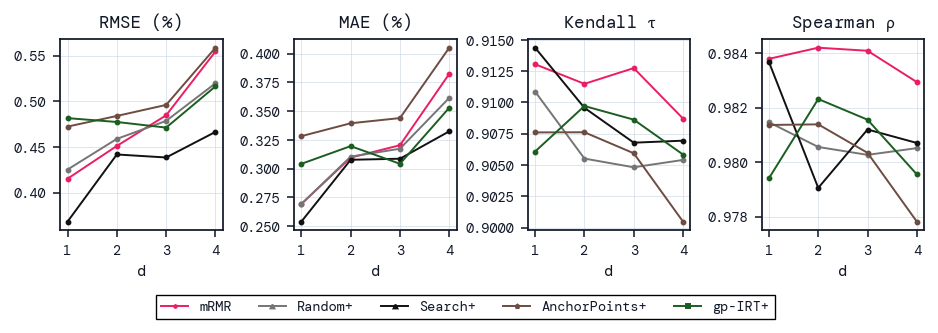

ablation_1b_passk_k1_metric_vs_degree.pdf


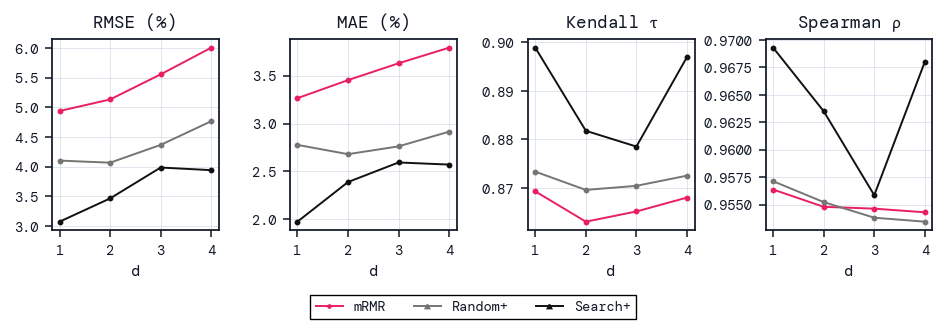

ablation_1b_passk_k1_metric_vs_degree_plus.pdf


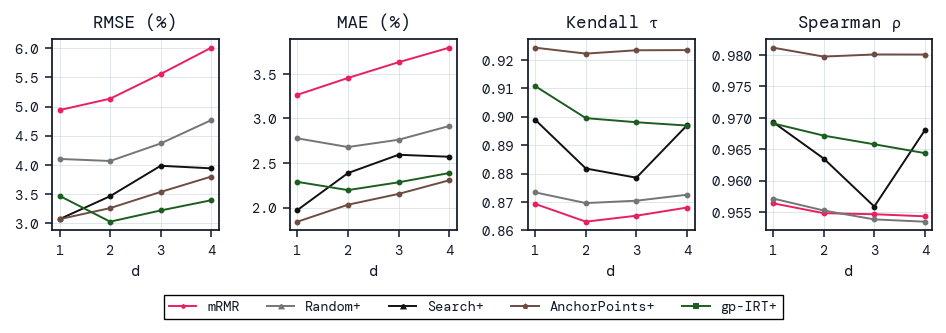

ablation_1b_passk_kopt_metric_vs_degree.pdf


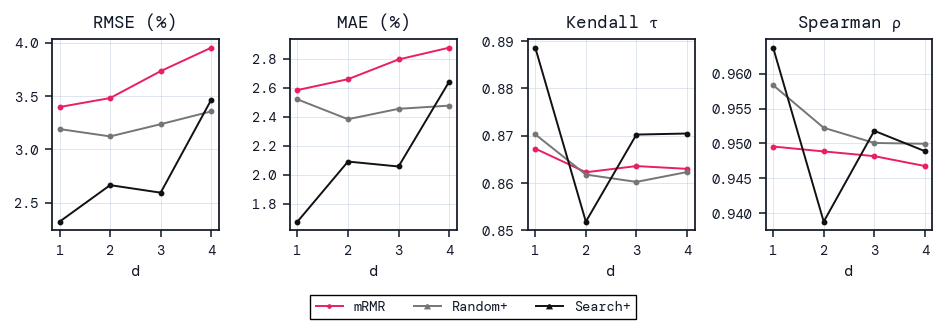

ablation_1b_passk_kopt_metric_vs_degree_plus.pdf


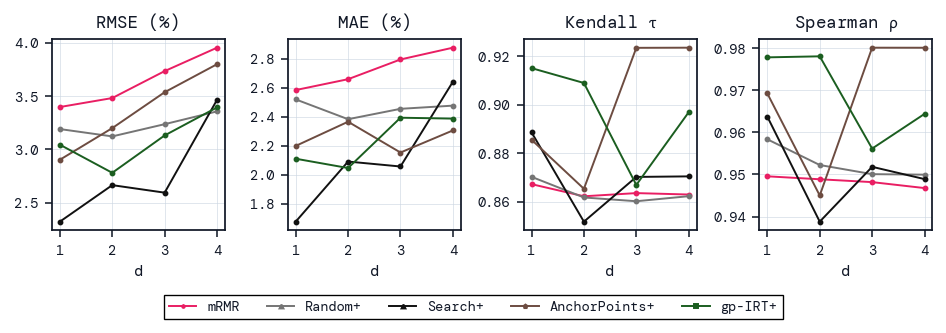

In [5]:
# Ablation 1B
outputs_1b, figures_1b = run_notebook_06_ablation_1b(**COMMON_ABLATION_KWARGS)
print(outputs_1b)
import matplotlib.pyplot as plt
for key, fig in figures_1b.items():
    print(key)
    display(fig)
    plt.close(fig)

[PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/06_ablations/ablation_2_mik_binary.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/06_ablations/ablation_2_mik_continuous.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/06_ablations/ablation_2_mik_passk_k1.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/06_ablations/ablation_2_mik_passk_kopt.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/06_ablations/ablation_2_mik_continuous_cat_main_fc2.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/06_ablations/ablation_2_mik_passk_k1_fc2.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/06_ablations/ablation_2_mik_passk_kopt_fc2.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/06_ablations/tables/ablation_2_binary.tex'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/06_ablations/tables/ablation_2_continuous.tex'), Pos

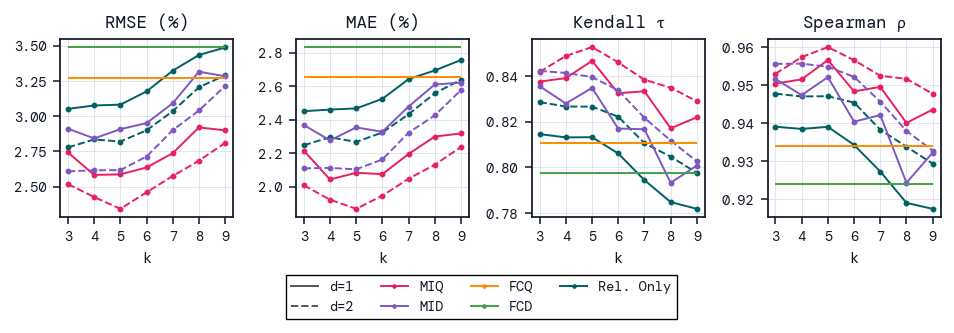

ablation_2_mik_continuous.pdf


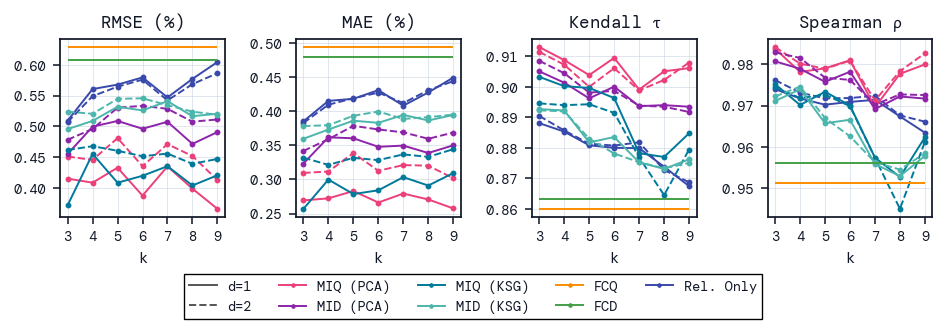

ablation_2_mik_passk_k1.pdf


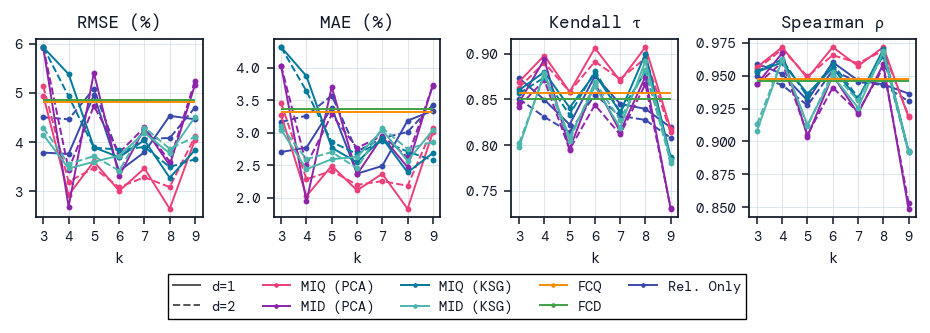

ablation_2_mik_passk_kopt.pdf


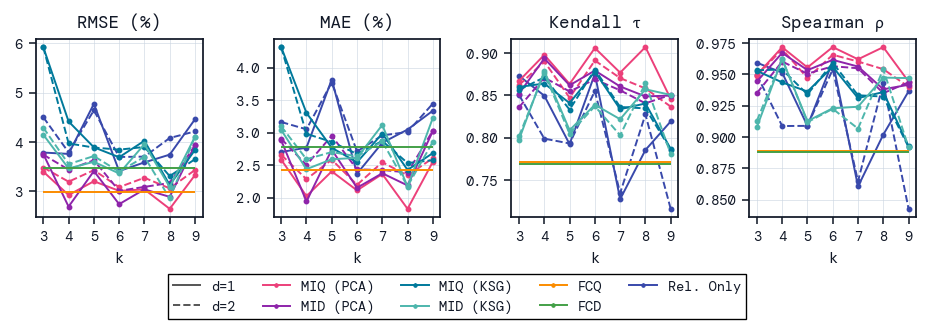

ablation_2_mik_continuous_cat_main_fc2.pdf


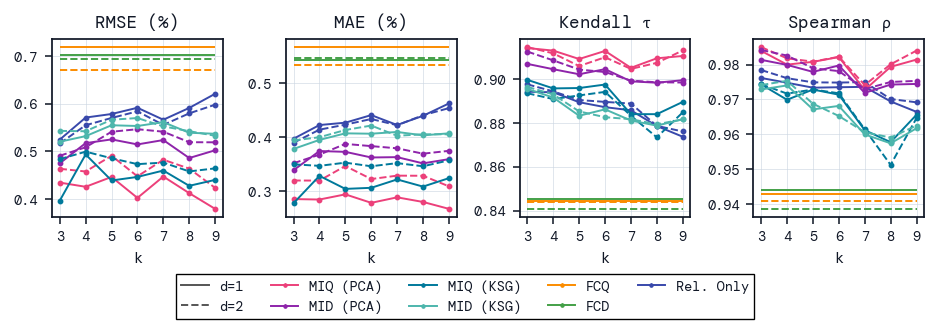

ablation_2_mik_passk_k1_fc2.pdf


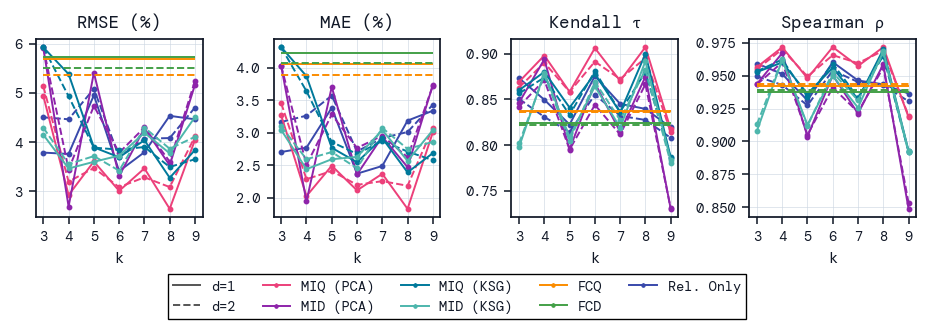

ablation_2_mik_passk_kopt_fc2.pdf


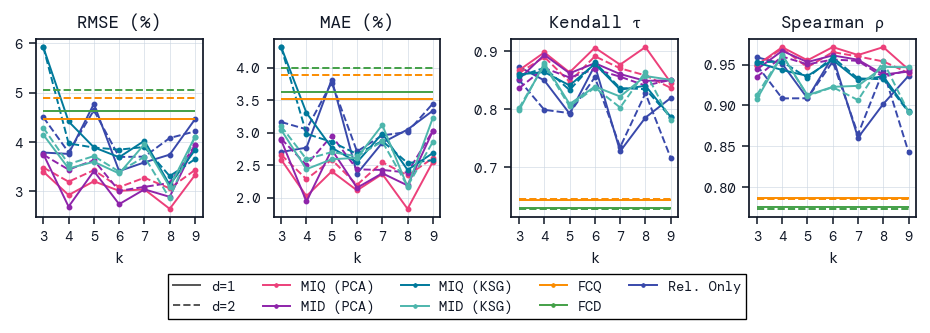

In [13]:
# Ablation 2
outputs_2, figures_2 = run_notebook_06_ablation_2(**COMMON_ABLATION_KWARGS)
print(outputs_2)
import matplotlib.pyplot as plt
for key, fig in figures_2.items():
    print(key)
    display(fig)
    plt.close(fig)

[PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/06_ablations/ablation_3_target_predictor_binary.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/06_ablations/tables/ablation_3_binary.tex')]
ablation_3_target_predictor_binary.pdf


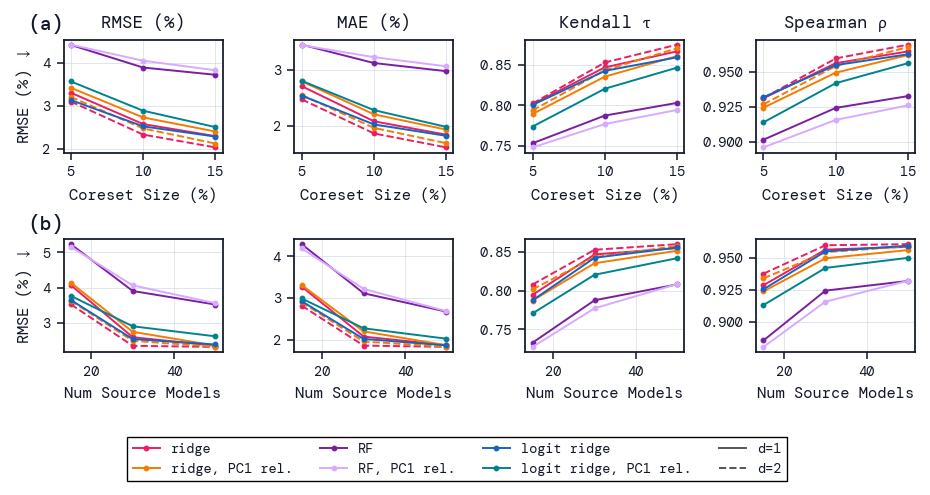

In [11]:
# Ablation 3
outputs_3, figures_3 = run_notebook_06_ablation_3(**COMMON_ABLATION_KWARGS)
print(outputs_3)
import matplotlib.pyplot as plt
for key, fig in figures_3.items():
    print(key)
    display(fig)
    plt.close(fig)

[PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/06_ablations/ablation_4_irt_binary.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/06_ablations/ablation_4_irt_binary_gpirt_only.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/06_ablations/ablation_4_irt_continuous.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/06_ablations/ablation_4_irt_continuous_gpirt_only.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/06_ablations/ablation_4_irt_passk_k1.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/06_ablations/ablation_4_irt_passk_k1_gpirt_only.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/06_ablations/ablation_4_irt_passk_kopt.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/06_ablations/ablation_4_irt_passk_kopt_gpirt_only.pdf'), PosixPath('/home/dg22309/Documents/mrmr_project/mrmr/viz/plots/06_ablations/tables/ablation_4_b

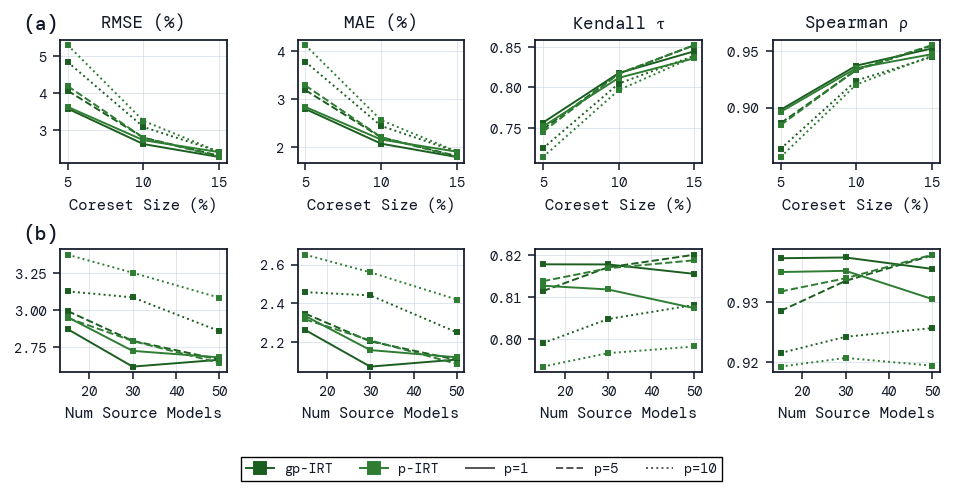

ablation_4_irt_binary_gpirt_only.pdf


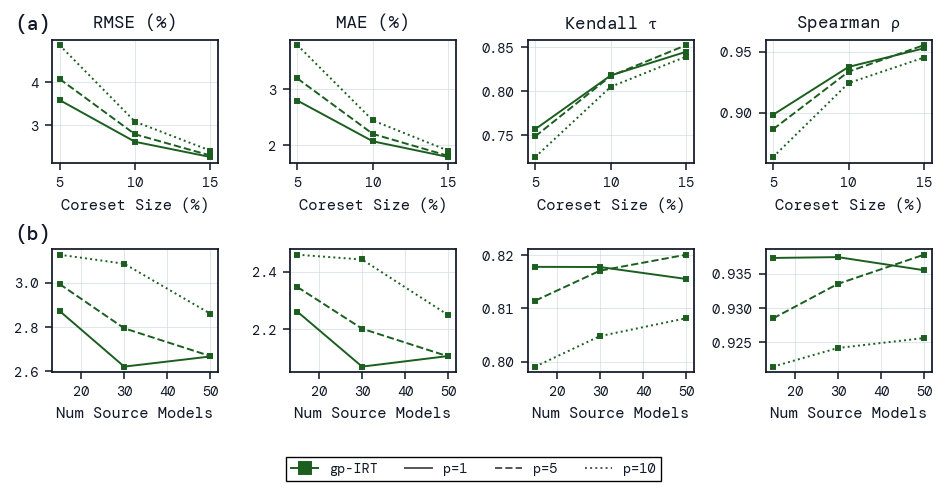

ablation_4_irt_continuous.pdf


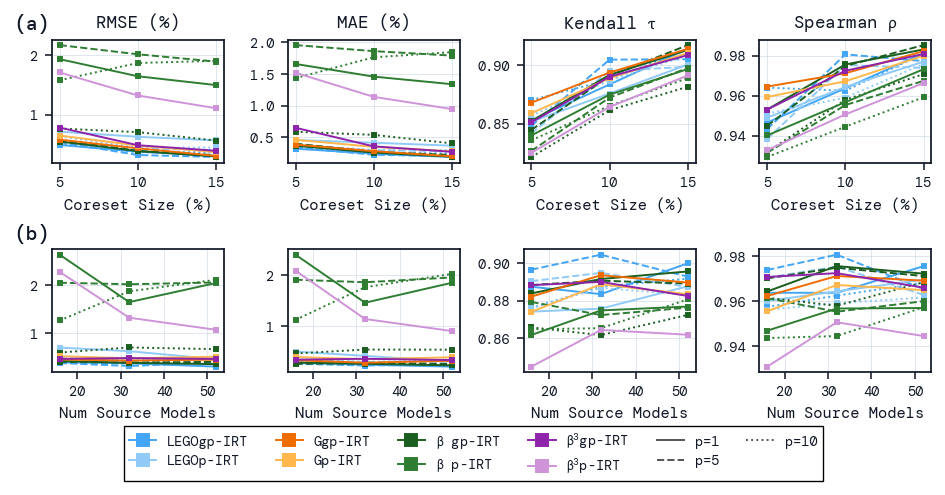

ablation_4_irt_continuous_gpirt_only.pdf


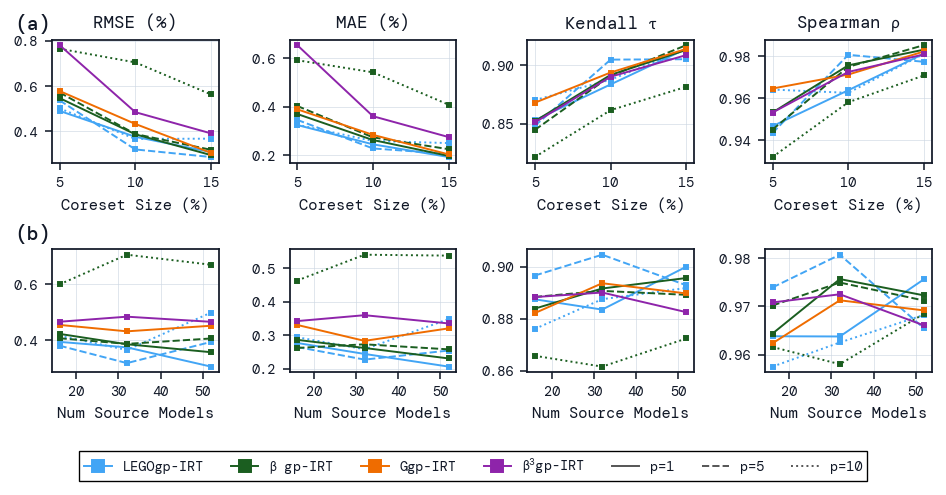

ablation_4_irt_passk_k1.pdf


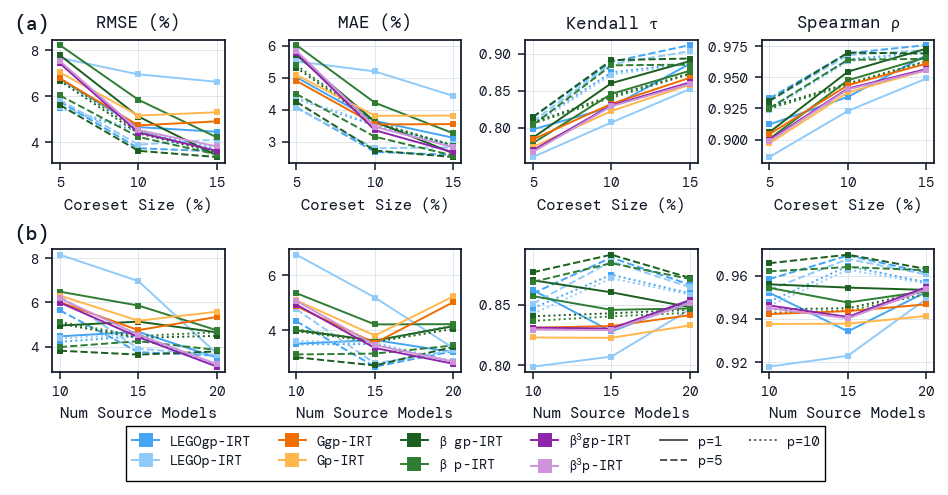

ablation_4_irt_passk_k1_gpirt_only.pdf


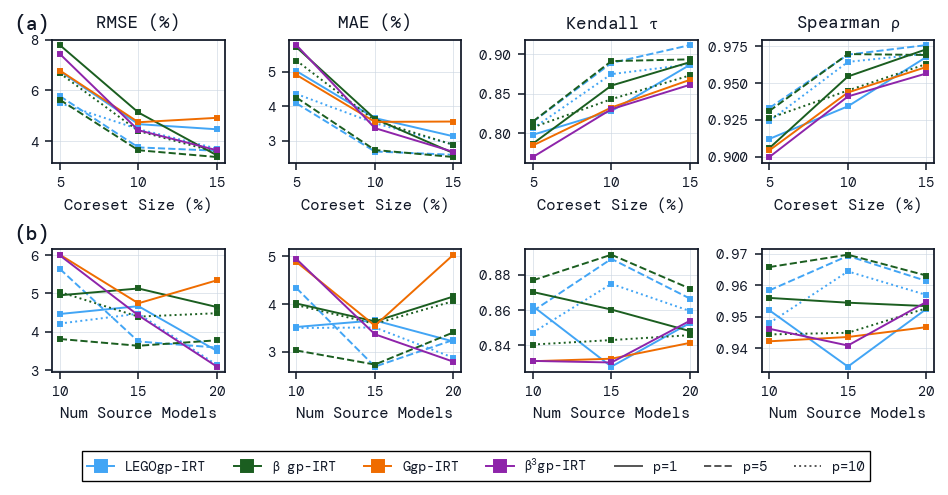

ablation_4_irt_passk_kopt.pdf


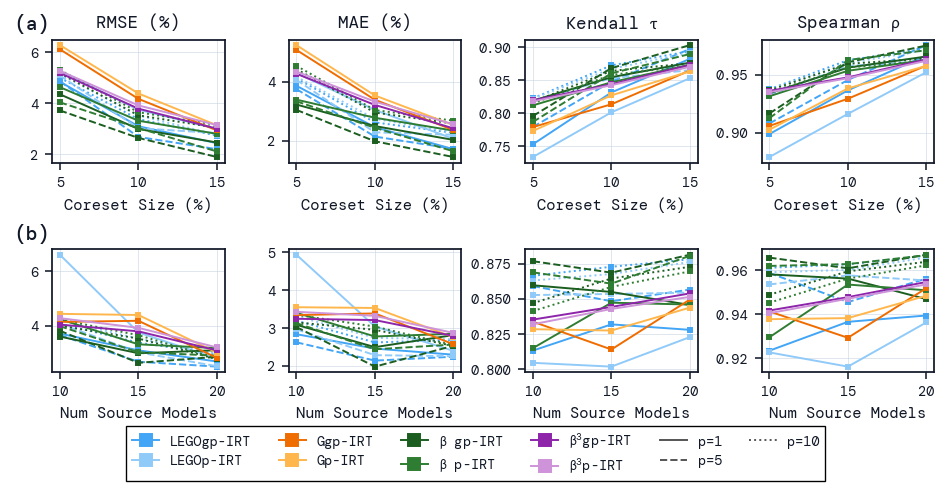

ablation_4_irt_passk_kopt_gpirt_only.pdf


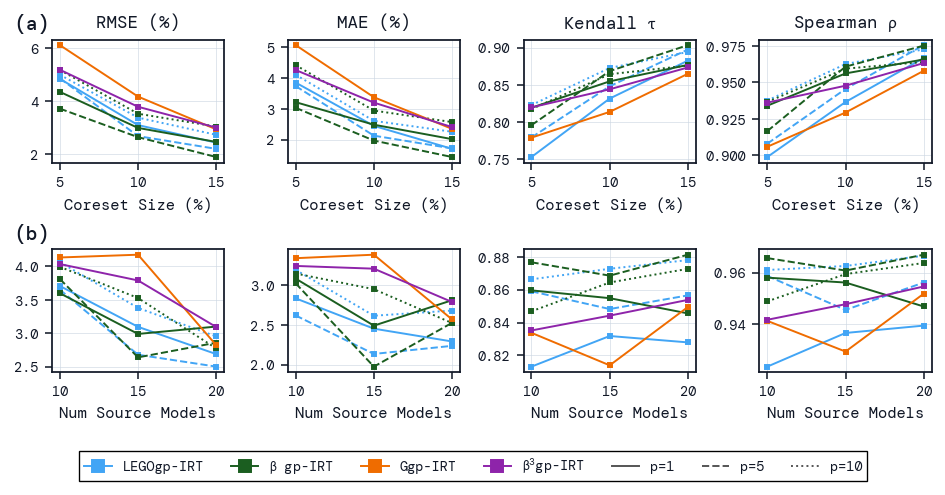

In [12]:
# Ablation 4
outputs_4, figures_4 = run_notebook_06_ablation_4(**COMMON_ABLATION_KWARGS)
print(outputs_4)
import matplotlib.pyplot as plt
for key, fig in figures_4.items():
    print(key)
    display(fig)
    plt.close(fig)

TypeError: can only concatenate list (not "str") to list

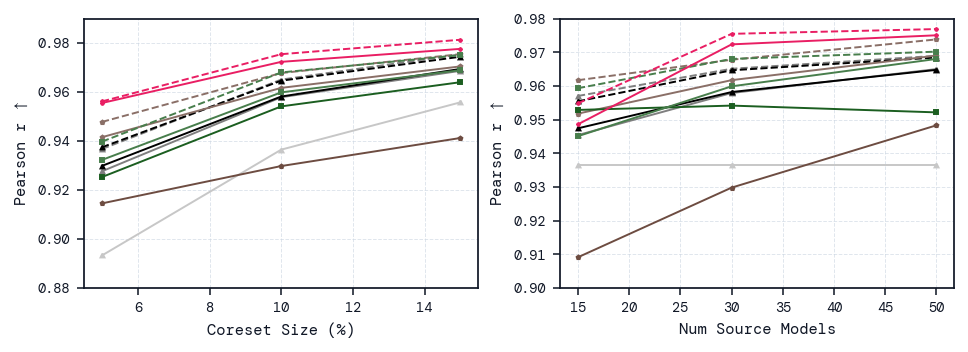

In [13]:
# Ablation 5 (optional, only if Pearson is present)
outputs_5, figures_5 = run_notebook_06_ablation_5(**COMMON_ABLATION_KWARGS)
print(outputs_5)
import matplotlib.pyplot as plt
for key, fig in figures_5.items():
    print(key)
    display(fig)
    plt.close(fig)